In [53]:
# importing necessasry libraries for data exploration
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import seaborn as sns

In [54]:
# reading dataset
ccf = pd.read_csv('credit_card_fraud.csv')
ccf.head()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,43.753735,-111.454923,0


In [55]:
#viewing data information
ccf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  339607 non-null  object 
 1   merchant               339607 non-null  object 
 2   category               339607 non-null  object 
 3   amt                    339607 non-null  float64
 4   city                   339607 non-null  object 
 5   state                  339607 non-null  object 
 6   lat                    339607 non-null  float64
 7   long                   339607 non-null  float64
 8   city_pop               339607 non-null  int64  
 9   job                    339607 non-null  object 
 10  dob                    339607 non-null  object 
 11  trans_num              339607 non-null  object 
 12  merch_lat              339607 non-null  float64
 13  merch_long             339607 non-null  float64
 14  is_fraud               339607 non-nu

In [56]:
# viewing dataset size
ccf.shape

(339607, 15)

In [57]:
# statistical summery of numerical data in dataset
ccf.describe()

,amt,lat,long,city_pop,merch_lat,merch_long,is_fraud
count,339607.000000,339607.000000,339607.000000,3.396070e+05,339607.000000,339607.000000,339607.000000
mean,70.577984,39.718991,-110.622605,1.071409e+05,39.718853,-110.622383,0.005247
std,161.675242,5.094961,12.651370,2.930299e+05,5.130894,12.663998,0.072248
min,1.000000,20.027100,-165.672300,4.600000e+01,19.027422,-166.671575,0.000000
25%,9.600000,36.715400,-120.093600,4.710000e+02,36.817194,-119.823755,0.000000
50%,46.460000,39.617100,-111.098500,1.645000e+03,39.586209,-111.036443,0.000000
75%,83.350000,41.710000,-100.621500,3.543900e+04,42.193072,-100.353096,0.000000
max,28948.900000,66.693300,-89.628700,2.383912e+06,67.510267,-88.629203,1.000000


In [58]:
# finding null values present in dataset
ccf.isnull().sum()

,0
trans_date_trans_time,0
merchant,0
category,0
amt,0
city,0
state,0
lat,0
long,0
city_pop,0
job,0


In [59]:
# Detecting outliers in dataset using IQR method

import numpy as np

def find_outliers_iqr(ccf, column):
    Q1 = ccf[column].quantile(0.25)
    Q3 = ccf[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    outliers = ccf[(ccf[column] < lower_bound) | (ccf[column] > upper_bound)]
    return outliers

outliers = find_outliers_iqr(ccf, "amt")

Q1: 9.6
Q3: 83.35
IQR: 73.75
Lower bound: -101.025
Upper bound: 193.975


In [60]:
# print outliers
print("Outliers in 'amt':")
display(find_outliers_iqr(ccf, 'amt'))

Outliers in 'amt':
Q1: 9.6
Q3: 83.35
IQR: 73.75
Lower bound: -101.025
Upper bound: 193.975


,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0
14,2019-01-01 00:56:12,"Swaniawski, Lowe and Robel",shopping_pos,317.14,Parks,AZ,35.2563,-111.9500,759,"Geologist, engineering",1957-03-28,3fe3286b0ea3f8c8857ec2e3da17b853,35.268124,-112.682895,0
16,2019-01-01 01:00:48,Howe Lt,misc_pos,218.71,Littleton,CO,39.5994,-105.0044,320420,Water engineer,1975-07-31,43204045928cb3449edc63078a75b48c,39.335171,-104.102882,0
21,2019-01-01 01:22:56,Fisher-Schowalte,shopping_net,226.33,June Lake,CA,37.7773,-119.0825,633,Health service manager,1927-09-09,208e003f309f9db37b3c40ddc9271908,36.819789,-119.670559,0
22,2019-01-01 01:23:00,Medhurst PLC,shopping_net,215.99,Sixes,OR,42.8250,-124.4409,217,Retail merchandiser,1928-10-01,e13482d8e24ed41362ff84bb9f100623,42.988724,-123.904978,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339286,2020-12-31 14:41:38,Erdman-Durgan,health_fitness,273.87,Superior,AZ,33.2887,-111.0985,2872,Petroleum engineer,1987-10-28,62834ff34ba6f099400885483cbdb290,33.134710,-111.799428,0
339372,2020-12-31 17:22:33,"Ritchie, Oberbrunner and Cremin",travel,472.18,Dumont,CO,39.7532,-105.6356,565,Mental health nurse,1978-08-27,e27d6665781250b98acfa84b8b3bdca4,39.611883,-105.048060,0
339492,2020-12-31 20:32:08,Hermann and Sons,shopping_pos,295.91,Burbank,WA,46.1966,-118.9017,3684,Musician,1981-11-29,d63e1eeef5c298201993aa8ad20e1c8c,47.102240,-119.832177,0
339515,2020-12-31 21:08:01,Mayert Group,shopping_pos,1309.21,Meridian,ID,43.6498,-116.4306,84106,Intelligence analyst,1971-02-11,7a848ec13987751c1b04be6006dc360f,42.916524,-115.787654,0


In [61]:
outliers.shape

(18043, 15)

In [62]:
lower_bound = ccf["amt"].min()
upper_bound = ccf["amt"].max()

clean_df = ccf[(ccf["amt"] >= lower_bound) & (ccf["amt"] <= upper_bound)]
clean_df.shape

(339607, 15)

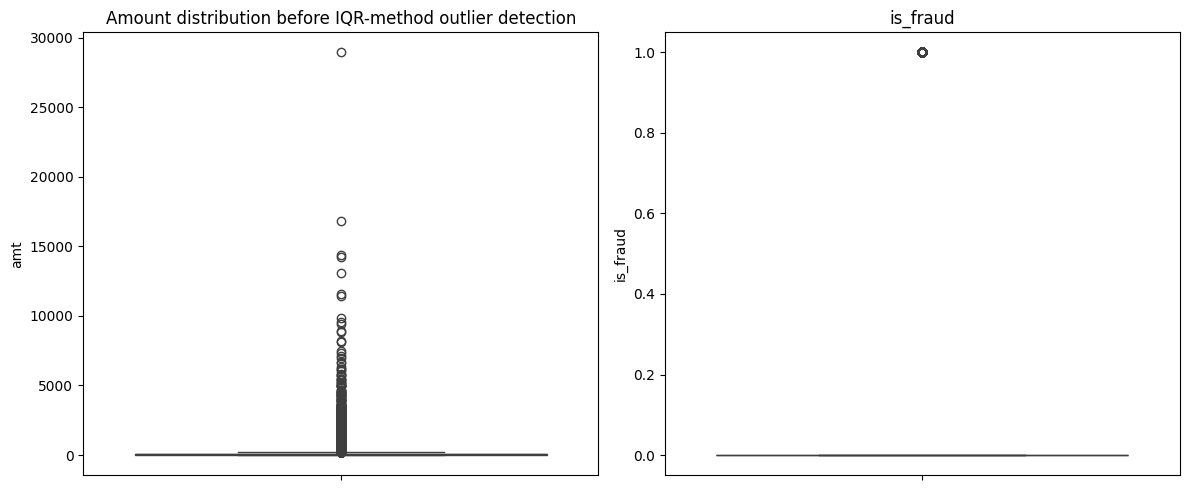

In [63]:
#Visualisation

# Before removing outliers
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.boxplot(y=ccf['amt'])
plt.title('Amount distribution before IQR-method outlier detection')
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.boxplot(y=ccf['is_fraud'])
plt.title('is_fraud')

plt.tight_layout()
plt.show()

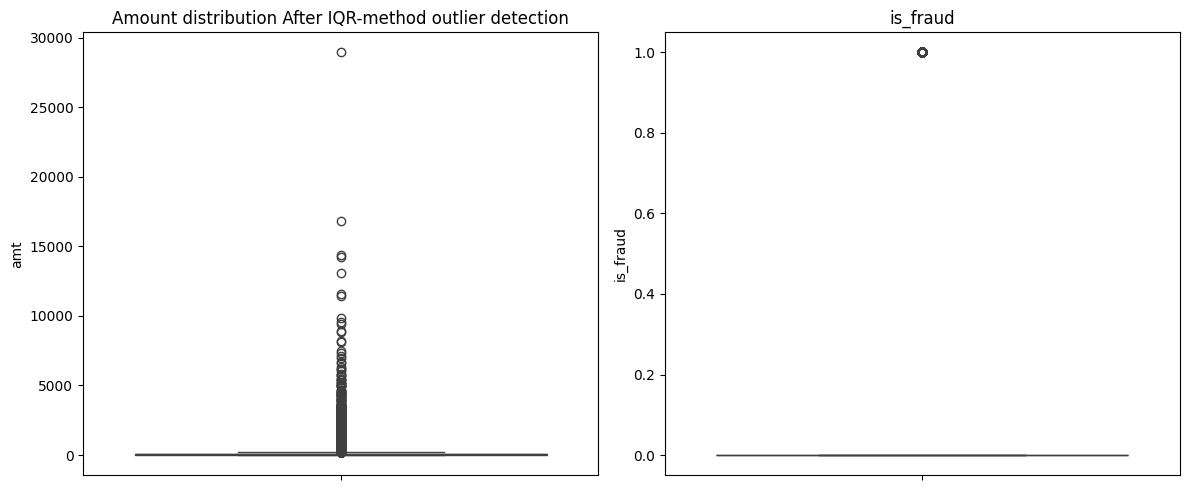

In [64]:
# After  removing outliers
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.boxplot(y=clean_df['amt'])
plt.title('Amount distribution After IQR-method outlier detection')
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.boxplot(y=clean_df['is_fraud'])
plt.title('is_fraud')

plt.tight_layout()
plt.show()

In [65]:
# featuire engineering
ccf['trans_date_trans_time'] = pd.to_datetime(ccf['trans_date_trans_time'])
ccf['dob'] = pd.to_datetime(ccf['dob'])

ccf['hour']  = ccf['trans_date_trans_time'].dt.hour
ccf['dow']   = ccf['trans_date_trans_time'].dt.dayofweek
ccf['month'] = ccf['trans_date_trans_time'].dt.month
ccf['age']   = (ccf['trans_date_trans_time'] - ccf['dob']).dt.days / 365.25

def haversine(lat1, lon1, lat2, lon2):
    """Straight-line distance in miles between two GPS coordinates."""
    R = 3958.8
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

ccf['dist_miles'] = haversine(ccf['lat'], ccf['long'], ccf['merch_lat'], ccf['merch_long'])

In [66]:
#separating target variable from others to train and test dataset

X=ccf.drop(columns=['is_fraud'])

In [67]:
X.head(5)

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,hour,dow,month,age,dist_miles
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0,1,1,40.531143,18.773185
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0,1,1,56.950034,67.236892
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0,1,1,73.029432,15.571163
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0,1,1,51.340178,41.024430
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,43.753735,-111.454923,0,1,1,51.416838,55.197630


In [68]:
y=ccf['is_fraud']
y.head(5)

,is_fraud
0,0
1,0
2,0
3,0
4,0


In [69]:
# featuire engineering
ccf['trans_date_trans_time'] = pd.to_datetime(ccf['trans_date_trans_time'])
ccf['dob'] = pd.to_datetime(ccf['dob'])

ccf['hour']  = ccf['trans_date_trans_time'].dt.hour
ccf['dow']   = ccf['trans_date_trans_time'].dt.dayofweek
ccf['month'] = ccf['trans_date_trans_time'].dt.month
ccf['age']   = (ccf['trans_date_trans_time'] - ccf['dob']).dt.days / 365.25

def haversine(lat1, lon1, lat2, lon2):
    """Straight-line distance in miles between two GPS coordinates."""
    R = 3958.8
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

ccf['dist_miles'] = haversine(ccf['lat'], ccf['long'], ccf['merch_lat'], ccf['merch_long'])

In [70]:
#Linear regression
from sklearn import linear_model
from sklearn.model_selection import train_test_split
cat_dummies = pd.get_dummies(ccf['category'], prefix='cat')
feature_cols = ['amt', 'hour', 'dow', 'month', 'age', 'dist_miles', 'city_pop']
X = pd.concat([ccf[feature_cols].reset_index(drop=True),
               cat_dummies.reset_index(drop=True)], axis=1)
y = ccf['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

In [71]:
regr = linear_model.LinearRegression()
regr.fit(X_train, y_train)
predicted = regr.predict(X_test)

In [72]:
print (regr.intercept_)

-0.01709349566662742


In [73]:
print(regr.coef_)

[ 9.30743818e-05  8.95970467e-04  8.46386412e-05 -3.52922457e-04
  1.28127538e-04  2.01460338e-06  1.29289235e-09 -4.81609734e-03
 -4.86646754e-03  6.04687803e-03  5.94621297e-03  9.39118156e-03
 -6.36065709e-03 -6.54367263e-03 -6.03670582e-03  1.22055283e-02
  1.30972170e-03 -4.67087053e-03  8.56079383e-03  1.93369473e-04
 -1.03592149e-02]


In [74]:
#logistic regression

from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
print('Accuracy of Logistic regression classifier on training set: {:.2f}'
     .format(logreg.score(X_train, y_train)))
print('Accuracy of Logistic regression classifier on test set: {:.2f}'
     .format(logreg.score(X_test, y_test)))

Accuracy of Logistic regression classifier on training set: 0.99
Accuracy of Logistic regression classifier on test set: 0.99


In [75]:
from sklearn.metrics import r2_score
Y_pred=regr.predict(X_test)
score=r2_score(y_test,Y_pred)
print(score)

0.033040003938366924


<Axes: ylabel='is_fraud'>

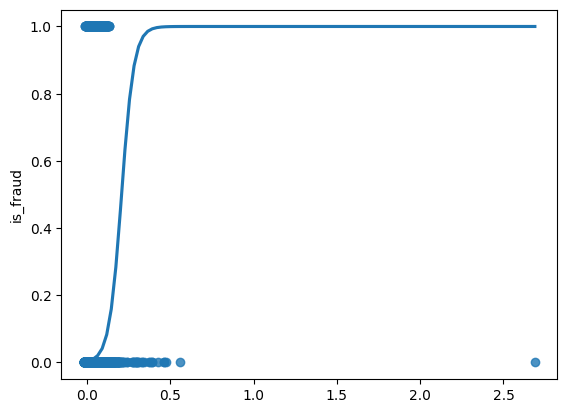

In [76]:
sns.regplot(x=Y_pred, y=y_test, data=X, logistic=True, ci=None)

In [78]:
#correlation analysis
corr=ccf.corr(numeric_only=True)
corr

,amt,lat,long,city_pop,merch_lat,merch_long,is_fraud,hour,dow,month,age,dist_miles
amt,1.000000,0.002817,-0.007017,0.006050,0.002957,-0.006891,0.201023,-0.032631,-0.001238,-0.001089,-0.011477,0.001497
lat,0.002817,1.000000,-0.151364,-0.236336,0.993646,-0.151267,0.009239,-0.012251,0.004584,-0.003718,0.162090,-0.073897
long,-0.007017,-0.151364,1.000000,-0.066080,-0.150385,0.998960,-0.004494,0.022051,0.000809,-0.000303,-0.092059,0.019237
city_pop,0.006050,-0.236336,-0.066080,1.000000,-0.235019,-0.066052,0.002338,0.009314,-0.001141,0.000913,-0.135260,0.019247
merch_lat,0.002957,0.993646,-0.150385,-0.235019,1.000000,-0.150278,0.008848,-0.011991,0.004591,-0.003587,0.161170,-0.073912
merch_long,-0.006891,-0.151267,0.998960,-0.066052,-0.150278,1.000000,-0.004550,0.021973,0.000621,-0.000206,-0.091797,0.019315
is_fraud,0.201023,0.009239,-0.004494,0.002338,0.008848,-0.004550,1.000000,0.012388,0.002127,-0.017812,0.012645,-0.000012
hour,-0.032631,-0.012251,0.022051,0.009314,-0.011991,0.021973,0.012388,1.000000,-0.000361,-0.002172,-0.157525,0.001753
dow,-0.001238,0.004584,0.000809,-0.001141,0.004591,0.000621,0.002127,-0.000361,1.000000,-0.003789,-0.005003,0.000717
month,-0.001089,-0.003718,-0.000303,0.000913,-0.003587,-0.000206,-0.017812,-0.002172,-0.003789,1.000000,0.017541,0.000862


<Axes: >

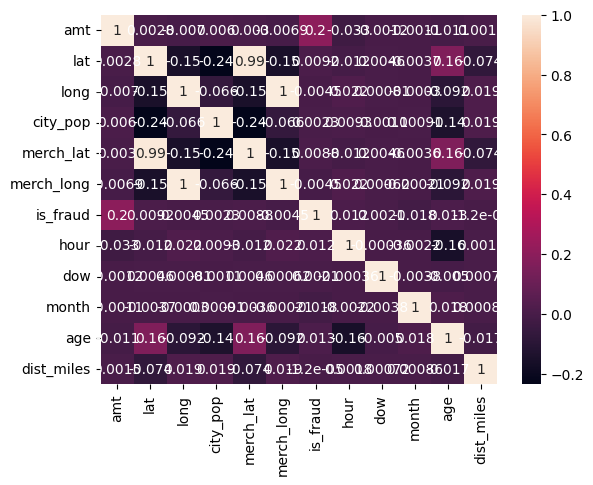

In [79]:
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns,annot=True)

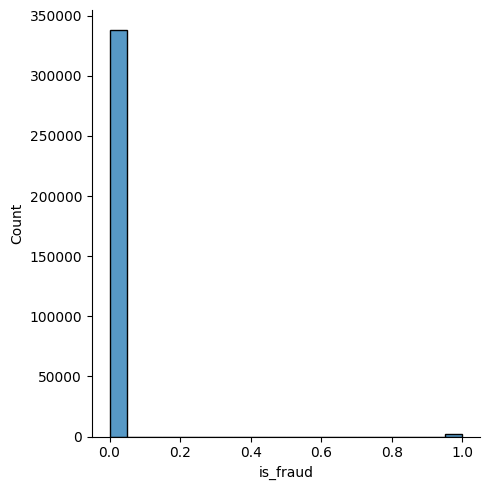

In [80]:
sns.displot(ccf['is_fraud'])

In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, recall_score,
                             precision_score, f1_score)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)


In [83]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[feature_cols] = scaler.fit_transform(X_train[feature_cols])
X_test[feature_cols]  = scaler.transform(X_test[feature_cols])

In [84]:
#SMOTE — handle severe class imbalance
sm = SMOTE(random_state=42, sampling_strategy=0.2)
X_res, y_res = sm.fit_resample(X_train, y_train)
print(f"After SMOTE: {len(X_res):,} training samples | Fraud: {y_res.sum():,}")

After SMOTE: 324,310 training samples | Fraud: 54,051


In [86]:
from sklearn.ensemble import RandomForestClassifier
# Baseline
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_res, y_res)

# Primary model

rf = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    max_depth=15, min_samples_leaf=2,
    n_jobs=-1, random_state=42
)
rf.fit(X_res, y_res)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=2, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [87]:
rf_proba = rf.predict_proba(X_test)[:, 1]
lr_proba = lr.predict_proba(X_test)[:, 1]

THRESHOLD = 0.30   # <-- lowered from 0.50 to maximise recall
rf_pred = (rf_proba >= THRESHOLD).astype(int)
lr_pred = (lr_proba >= 0.50).astype(int)

In [88]:
print("\n── Logistic Regression ──")
print(classification_report(y_test, lr_pred, target_names=['Legit', 'Fraud']))

print("\n── Random Forest (threshold=0.30) ──")
print(classification_report(y_test, rf_pred, target_names=['Legit', 'Fraud']))

print(f"\nRandom Forest ROC-AUC : {roc_auc_score(y_test, rf_proba):.4f}")
print(f"Recall  (fraud)       : {recall_score(y_test, rf_pred):.4f}  ← priority metric")
print(f"Precision (fraud)     : {precision_score(y_test, rf_pred):.4f}")
print(f"F1-Score  (fraud)     : {f1_score(y_test, rf_pred):.4f}")


── Logistic Regression ──
              precision    recall  f1-score   support

       Legit       1.00      0.91      0.95     67566
       Fraud       0.04      0.71      0.07       356

    accuracy                           0.91     67922
   macro avg       0.52      0.81      0.51     67922
weighted avg       0.99      0.91      0.95     67922


── Random Forest (threshold=0.30) ──
              precision    recall  f1-score   support

       Legit       1.00      0.99      0.99     67566
       Fraud       0.25      0.93      0.40       356

    accuracy                           0.99     67922
   macro avg       0.63      0.96      0.70     67922
weighted avg       1.00      0.99      0.99     67922


Random Forest ROC-AUC : 0.9936
Recall  (fraud)       : 0.9270  ← priority metric
Precision (fraud)     : 0.2533
F1-Score  (fraud)     : 0.3978


Text(183.22222222222223, 0.5, 'Actual')

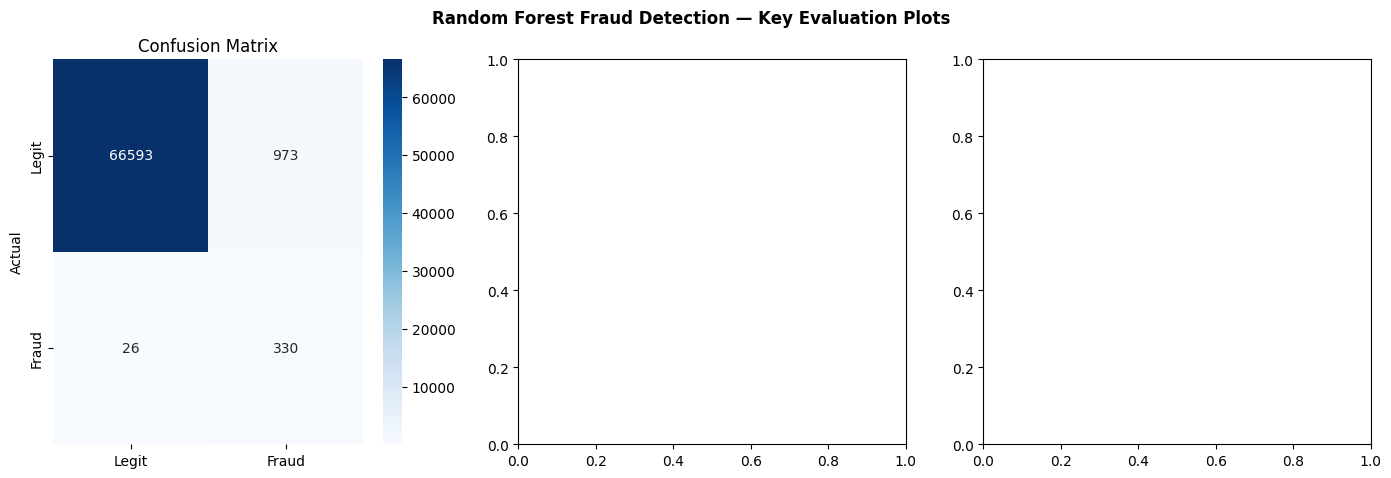

In [90]:
# Confusion matrix
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Random Forest Fraud Detection — Key Evaluation Plots', fontweight='bold')

cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
axes[0].set_title('Confusion Matrix'); axes[0].set_ylabel('Actual')

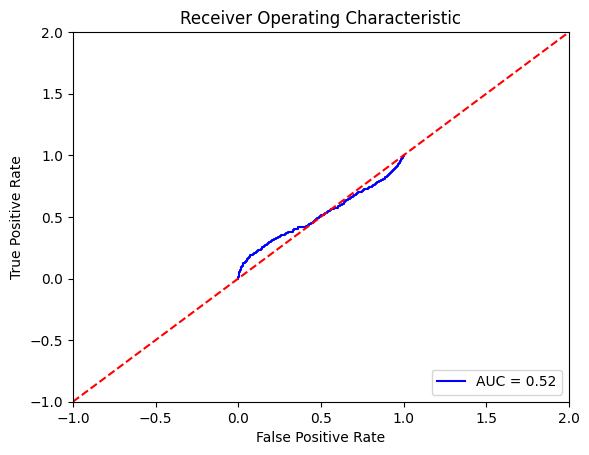

In [96]:
# calculate the fpr and tpr for all thresholds of the classification
probs = logreg.predict_proba(X_test)
preds = probs[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test, preds)
roc_auc = metrics.auc(fpr, tpr)


import matplotlib.pyplot as plt
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([-1, 2], [-1, 2],'r--')
plt.xlim([-1, 2])
plt.ylim([-1, 2])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [94]:
# Feature importance
fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values().tail(10)
fi.plot(kind='barh', ax=axes[2], color='#E67E22')
axes[2].set_title('Top 10 Feature Importances')

Text(0.5, 1.0, 'Top 10 Feature Importances')

In [95]:
plt.tight_layout()
plt.savefig('fraud_evaluation.png', dpi=150, bbox_inches='tight')
print("\nPlot saved to fraud_evaluation.png")


Plot saved to fraud_evaluation.png


<Figure size 640x480 with 0 Axes>

In [99]:
#Visualisations

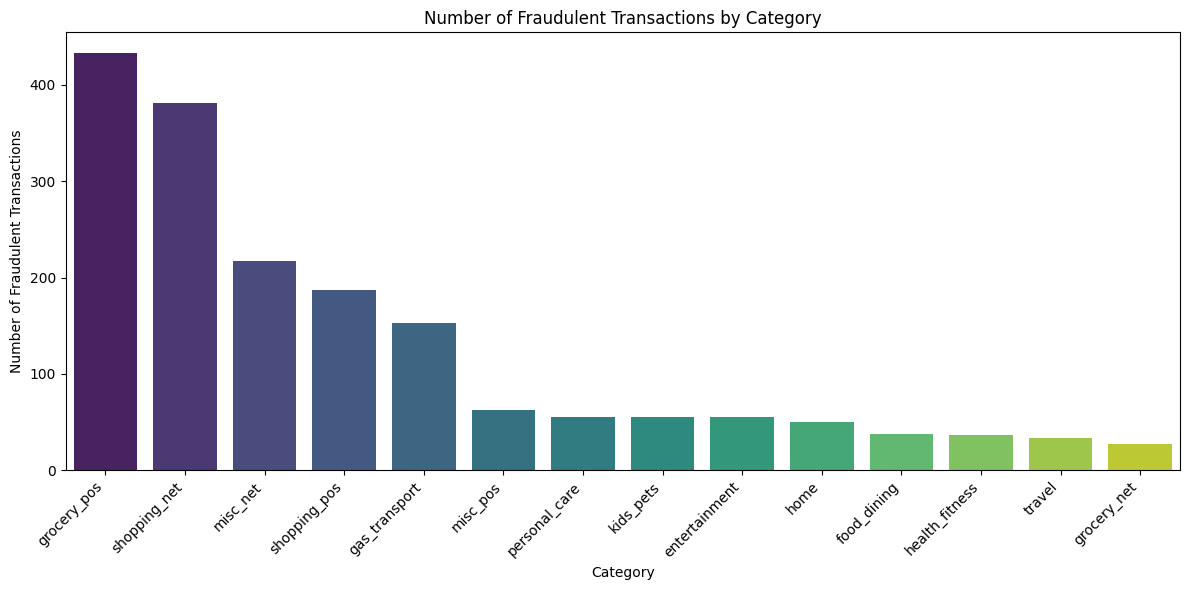

In [104]:
#visualisation of fraud happening in different platforms
fraud_by_category = ccf.groupby('category')['is_fraud'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=fraud_by_category.index, y=fraud_by_category.values, palette='viridis')
plt.title('Number of Fraudulent Transactions by Category')
plt.xlabel('Category')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
#find maximum fraud happenning city

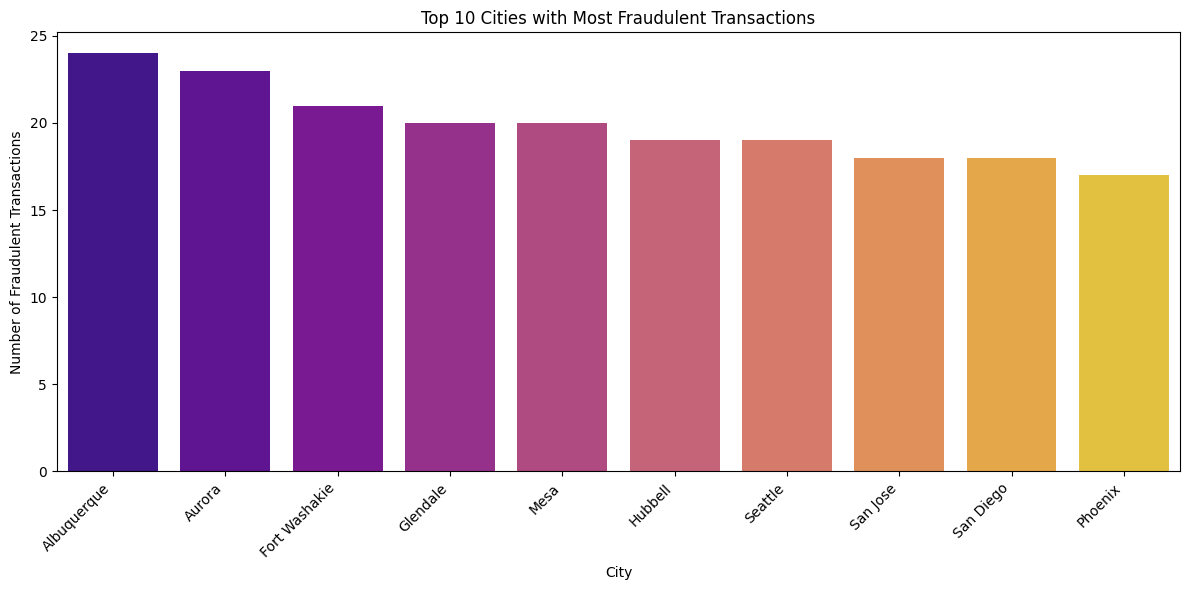

In [106]:
#finding maximum fraud happenning city
fraud_by_city = ccf.groupby('city')['is_fraud'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=fraud_by_city.head(10).index, y=fraud_by_city.head(10).values, palette='plasma')
plt.title('Top 10 Cities with Most Fraudulent Transactions')
plt.xlabel('City')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

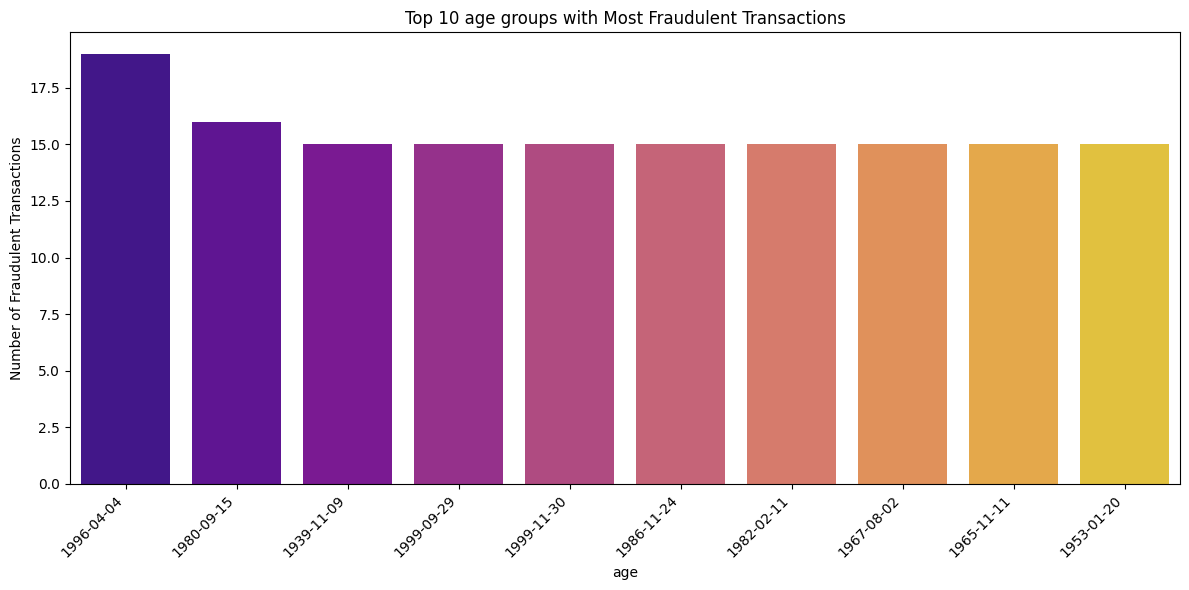

In [108]:
# finding which age group is effecting
fraud_by_age = ccf.groupby('dob')['is_fraud'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=fraud_by_age.head(10).index, y=fraud_by_age.head(10).values, palette='plasma')
plt.title('Top 10 age groups with Most Fraudulent Transactions')
plt.xlabel('age')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

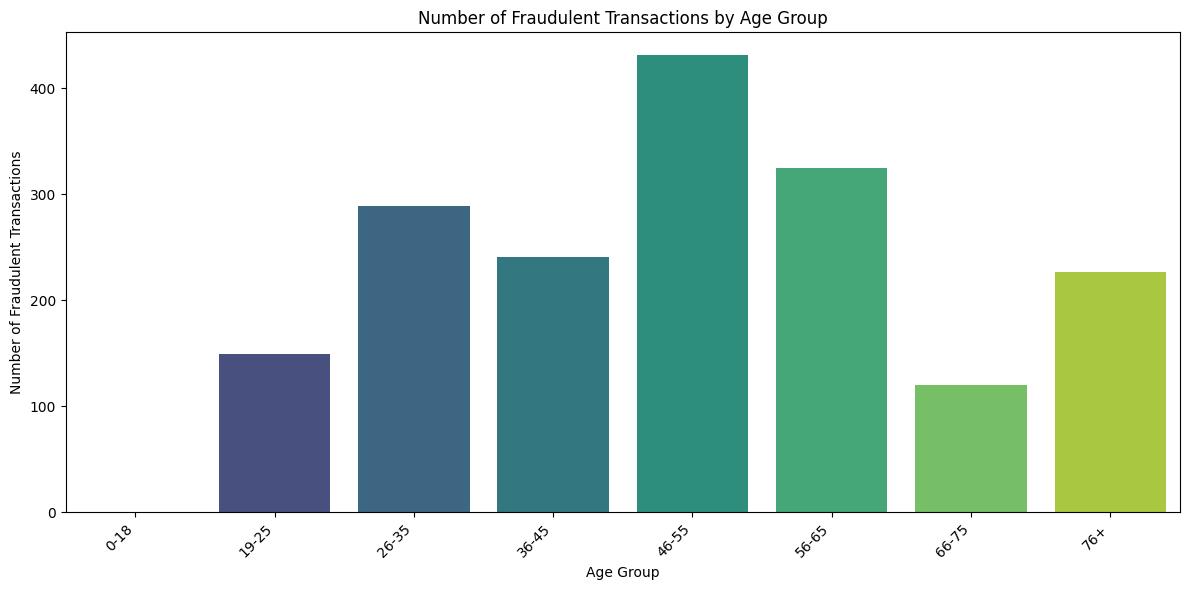

In [109]:
# Define age bins and labels
age_bins = [0, 18, 25, 35, 45, 55, 65, 75, 100]
age_labels = ['0-18', '19-25', '26-35', '36-45', '46-55', '56-65', '66-75', '76+']

# Create a new 'age_group' column
ccf['age_group'] = pd.cut(ccf['age'], bins=age_bins, labels=age_labels, right=False)

# Display the distribution of fraudulent transactions by age group
fraud_by_age_group = ccf.groupby('age_group')['is_fraud'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=fraud_by_age_group.index, y=fraud_by_age_group.values, palette='viridis')
plt.title('Number of Fraudulent Transactions by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

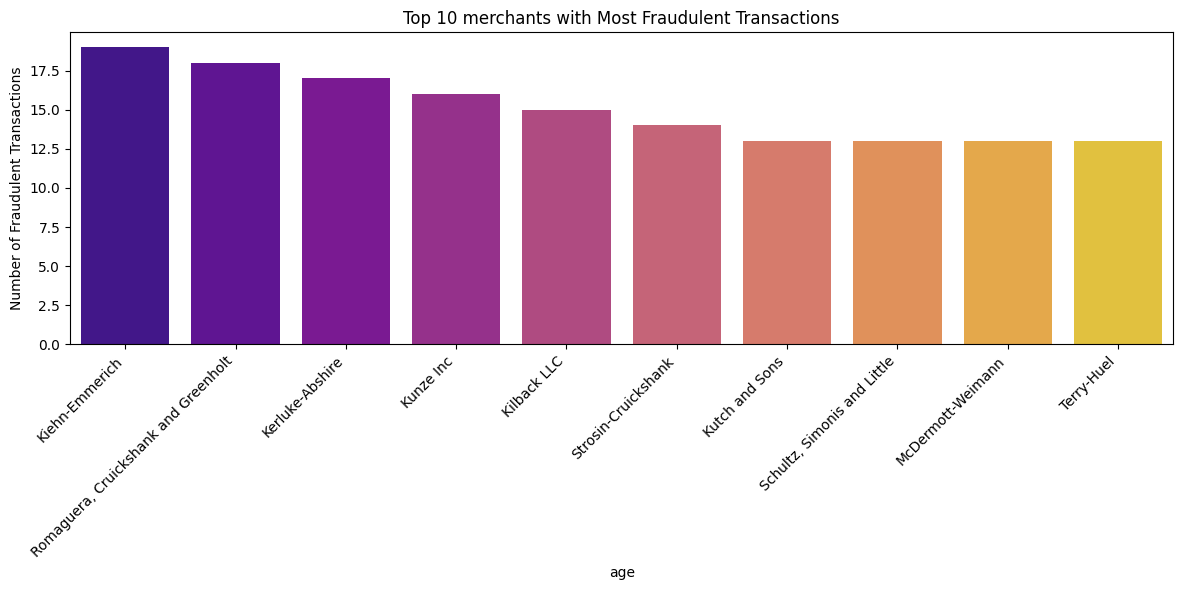

In [111]:
# top merchants effecting to fraud
fraud_by_merchant = ccf.groupby('merchant')['is_fraud'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=fraud_by_merchant.head(10).index, y=fraud_by_merchant.head(10).values, palette='plasma')
plt.title('Top 10 merchants with Most Fraudulent Transactions')
plt.xlabel('age')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Geospatial Visualization of Fraud Rates by State

To visualize fraud rates across states, we first need to calculate the fraud rate for each state and then merge this data with a geospatial dataset of US states.

In [112]:
# Calculate fraud rate per state
fraud_by_state = ccf.groupby('state')['is_fraud'].mean().reset_index()
fraud_by_state.rename(columns={'is_fraud': 'fraud_rate'}, inplace=True)

print("Fraud rates per state (top 5):\n")
display(fraud_by_state.sort_values(by='fraud_rate', ascending=False).head())

Fraud rates per state (top 5):



,state,fraud_rate
0,AK,0.016875
9,OR,0.007460
7,NE,0.006275
3,CO,0.005818
8,NM,0.005165


Next, we'll load a geospatial dataset of US states. A common source for this is a GeoJSON file. If you don't have one locally, you might need to download it. For this example, I'll assume a `us_states.json` or similar file is available. If not, please provide or download a suitable GeoJSON file for US states.

*Note: If the following cell fails due to `us_states.json` not being found, you will need to replace `us_states.json` with the path to your US states GeoJSON file.*

US states GeoJSON loaded and processed successfully.


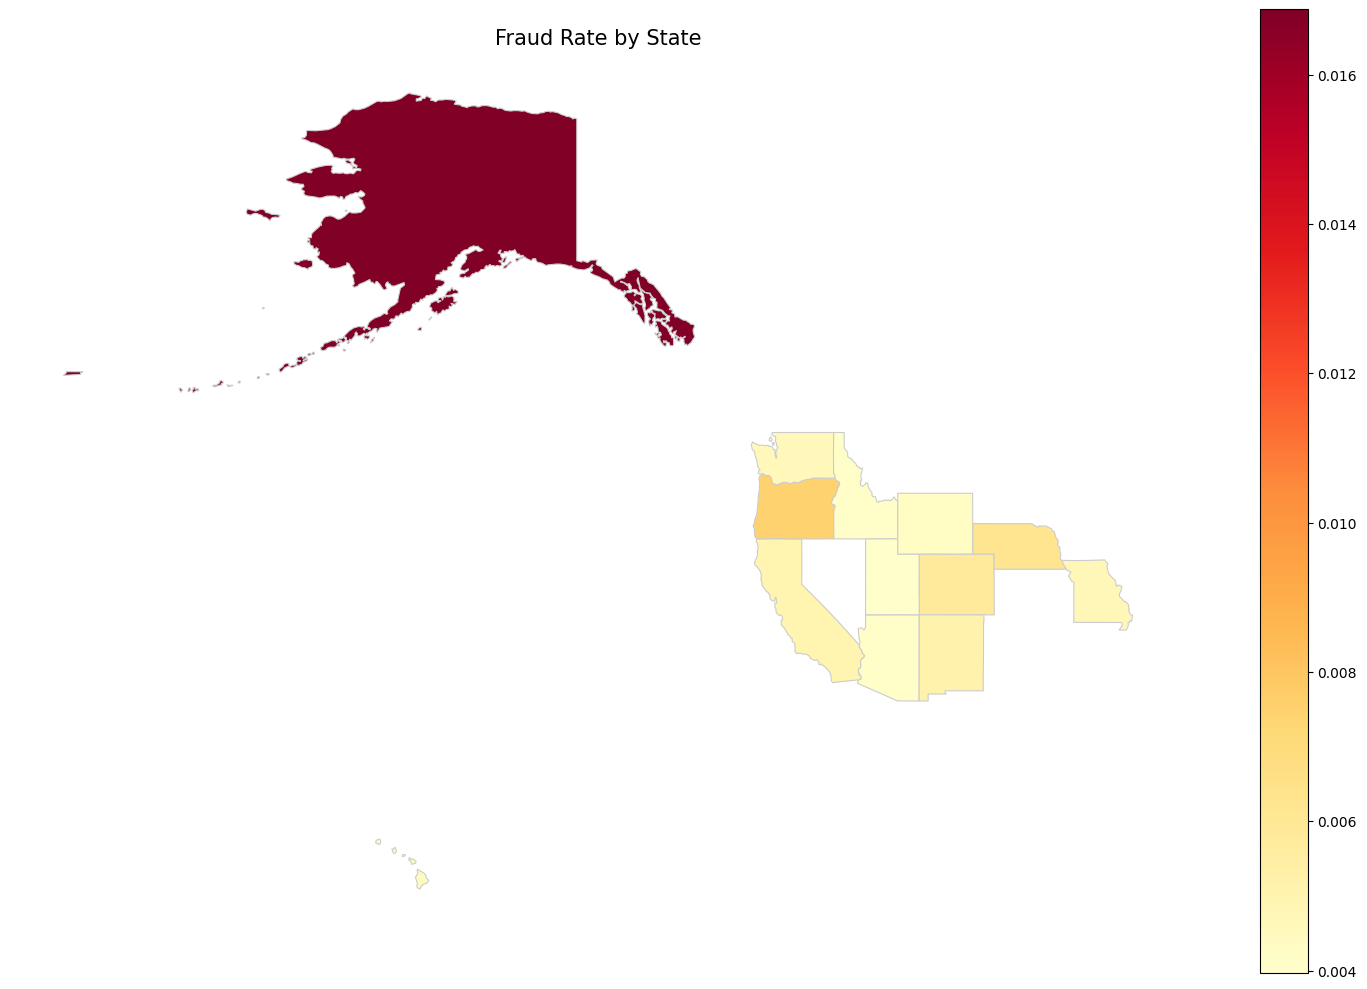

In [114]:
# Download the GeoJSON file for US states
# This file contains full state names, which will be mapped to abbreviations.
!wget -q https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json -O us_states.json

# Define a dictionary to map full state names to their abbreviations
state_name_to_abbrev = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH',
    'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC',
    'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA',
    'Rhode Island': 'RI', 'South Carolina': 'SC', 'South Dakota': 'SD', 'Tennessee': 'TN',
    'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
    'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY',
    'District of Columbia': 'DC'
}

# Load US states boundaries from the downloaded GeoJSON file
try:
    states_gdf = gpd.read_file('us_states.json')
    # Map the full state names in the GeoDataFrame to their abbreviations
    states_gdf['state'] = states_gdf['name'].map(state_name_to_abbrev)
    # Drop any rows where the state abbreviation could not be mapped (e.g., non-US territories if present)
    states_gdf.dropna(subset=['state'], inplace=True)
    print("US states GeoJSON loaded and processed successfully.")
except Exception as e:
    print(f"Error loading or processing US states GeoJSON: {e}")
    print("Could not create the geospatial plot.")
    # Create an empty GeoDataFrame to prevent further errors if loading fails
    from shapely.geometry import Polygon
    states_gdf = gpd.GeoDataFrame({'state': [], 'geometry': []}, crs="EPSG:4326")

# Merge fraud rates with the states GeoDataFrame
# Ensure both DataFrames have the 'state' column as their index for merging
if not states_gdf.empty:
    merged_gdf = states_gdf.set_index('state').join(fraud_by_state.set_index('state'))

    # Plotting the choropleth map
    fig, ax = plt.subplots(1, 1, figsize=(15, 10))
    merged_gdf.dropna(subset=['fraud_rate']).plot(column='fraud_rate', cmap='YlOrRd', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)

    ax.set_title('Fraud Rate by State', fontsize=15)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
else:
    print("No state data available to plot the geospatial map.")